# 05. PyTorch Batch Inference - GreenSpace CNN

Run a saved PyTorch/TorchGeo model on cached unseen images and export the same practical prediction schema as TensorFlow NB05.

Start with `LIMIT = 100`. Set `LIMIT = None` only after the smoke output is clean.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp')
print('PROJECT_ROOT:', PROJECT_ROOT)


PROJECT_ROOT: /Users/starsrain/2025_codeProject/GreenSpace_CNN


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src_torch.config import TORCH_DATA_CONFIG, TORCH_TRAINING_CONFIG, resolve_prediction_output_root
from src_torch.data import load_split_df
from src_torch.evaluation import (
    checkpoint_binary_cols,
    find_latest_pytorch_checkpoint,
    infer_run_tag_and_variant,
    load_torch_checkpoint_model,
)
from src_torch.inference import (
    build_prediction_dataframe,
    inference_output_tag,
    list_inference_image_paths,
    load_thresholds,
    predict_image_paths,
)
from src_torch.training import resolve_device


In [4]:
# Keep the selected production checkpoint explicit.
USE_MANUAL_MODEL = True
MANUAL_MODEL_PATH = PROJECT_ROOT / 'models/runs/PyTorch_20260614_220926/best_mcmae_PyTorch_20260614_220926.pt'

# Run 100 images first. Set to None only for the full cache.
LIMIT = None

if USE_MANUAL_MODEL:
    model_path = Path(MANUAL_MODEL_PATH)
    assert model_path.is_file(), f'Model not found: {model_path}'
else:
    model_path = find_latest_pytorch_checkpoint(preferred_variant='best_mcmae')

run_tag, variant = infer_run_tag_and_variant(model_path)
device = resolve_device(TORCH_TRAINING_CONFIG['device'])
model, model_config, checkpoint = load_torch_checkpoint_model(model_path, device=device)

# The checkpoint owns output order; do not derive it from a later live split.
binary_cols = checkpoint_binary_cols(model_config)
bin_names = [label[:-2] for label in binary_cols]
train_df = load_split_df('train')  # used only for the optional comparison plot below

threshold_path = PROJECT_ROOT / 'monitoring_output/runs' / run_tag / f'thresholds_{variant}.csv'
thresholds = load_thresholds(threshold_path, bin_names)

inference_cache = Path(os.getenv('GREENSPACE_INFERENCE_IMAGE_ROOT', PROJECT_ROOT / 'data/cache/inference_images'))
image_paths = list_inference_image_paths(inference_cache, limit=LIMIT)
output_tag = inference_output_tag(run_tag, LIMIT)

print('Checkpoint:', model_path)
print('Thresholds:', threshold_path)
print('Device:', device)
print('Images:', len(image_paths))
print('Binary labels:', bin_names)
print('Output tag:', output_tag)


Checkpoint: /Users/starsrain/2025_codeProject/GreenSpace_CNN/models/runs/PyTorch_20260614_220926/best_mcmae_PyTorch_20260614_220926.pt
Thresholds: /Users/starsrain/2025_codeProject/GreenSpace_CNN/monitoring_output/runs/PyTorch_20260614_220926/thresholds_best_mcmae.csv
Device: mps
Images: 15019
Binary labels: ['sports_field', 'multipurpose_open_area', 'children_s_playground', 'water_feature', 'walking_paths', 'built_structures', 'parking_lots']
Output tag: PyTorch_20260614_220926


In [5]:
predictions = predict_image_paths(
    model=model,
    image_paths=image_paths,
    device=device,
    batch_size=int(TORCH_DATA_CONFIG['batch_size']),
)
pred_df = build_prediction_dataframe(
    image_paths=image_paths,
    predictions=predictions,
    binary_labels=bin_names,
    thresholds=thresholds,
)

expected_columns = ['image_filename']
for name in bin_names:
    expected_columns.extend([f'{name}_prob', f'{name}_pred'])
expected_columns.extend(['shade_class', 'shade_confidence', 'score_ev', 'veg_ev'])
assert pred_df.columns.tolist() == expected_columns
assert len(pred_df) == len(image_paths)
assert pred_df['score_ev'].between(1.0, 5.0).all()
assert pred_df['veg_ev'].between(1.0, 5.0).all()

out_dir = resolve_prediction_output_root()
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'predictions_{output_tag}.csv'
pred_df.to_csv(out_path, index=False)

print(f'Saved {len(pred_df)} predictions to {out_path}')
pred_df.head()


Saved 15019 predictions to /Users/starsrain/2025_codeProject/GreenSpace_CNN/predictions/predictions_PyTorch_20260614_220926.csv


,image_filename,sports_field_prob,sports_field_pred,multipurpose_open_area_prob,multipurpose_open_area_pred,children_s_playground_prob,children_s_playground_pred,water_feature_prob,water_feature_pred,walking_paths_prob,walking_paths_pred,built_structures_prob,built_structures_pred,parking_lots_prob,parking_lots_pred,shade_class,shade_confidence,score_ev,veg_ev
0,USA_NY_00970-0003_1_0-00000_f00_p000.jpg,0.000581,0,0.492486,1,0.000469,0,0.607589,1,0.288217,0,0.002149,0,0.000926,0,abundant,0.693445,4.788926,3.983913
1,USA_NY_00970-0003_1_1-00000_f01_p000.jpg,0.000350,0,0.350147,0,0.000227,0,0.775713,1,0.587661,1,0.005869,0,0.002670,0,abundant,0.838701,4.756167,4.532756
2,USA_NY_00970-0003_1_12-00000_f04_p000.jpg,0.001411,0,0.684859,1,0.000743,0,0.220705,0,0.437821,1,0.004797,0,0.001493,0,minimal,0.648367,4.530133,3.701049
3,USA_NY_00970-0003_1_13-00000_f05_p000.jpg,0.007569,0,0.881102,1,0.003352,0,0.489892,1,0.557805,1,0.022470,0,0.005456,0,minimal,0.791833,4.250937,3.384761
4,USA_NY_00970-0003_1_14-00000_f06_p000.jpg,0.000812,0,0.900153,1,0.000380,0,0.983911,1,0.810349,1,0.006874,0,0.002560,0,minimal,0.993335,4.461082,2.060318


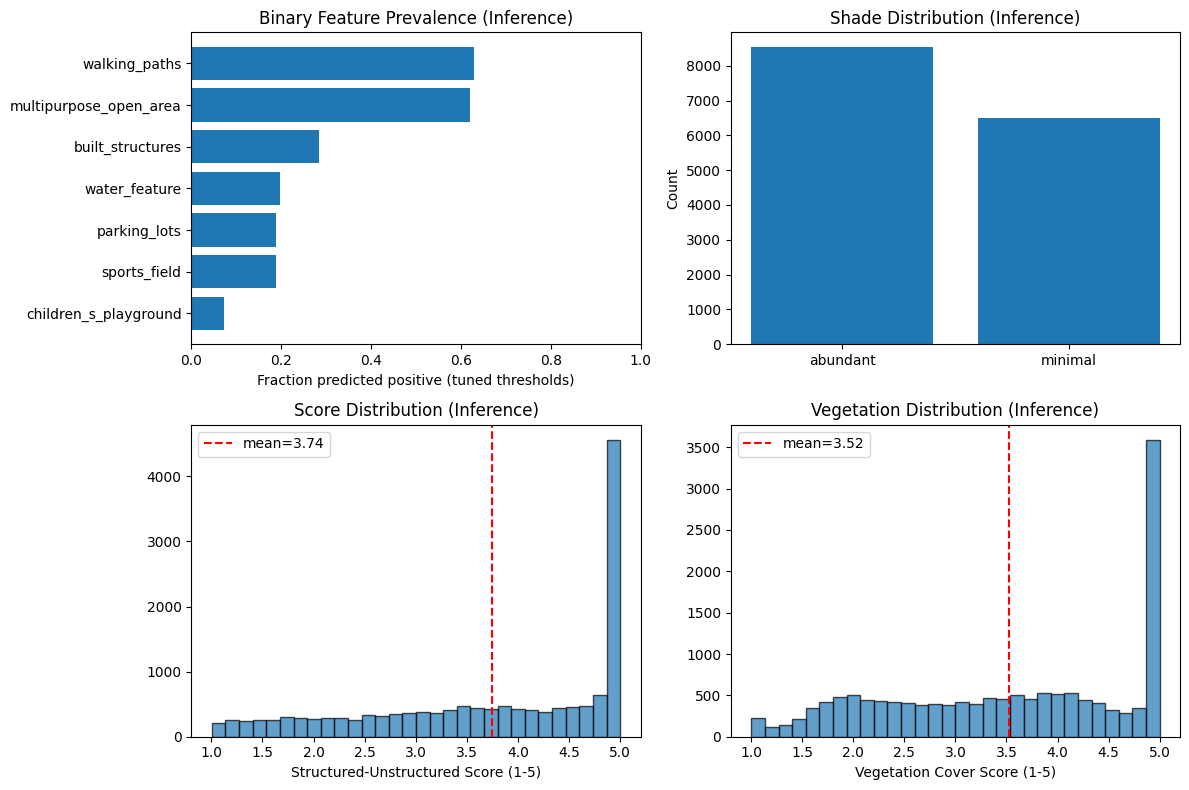

Score range: (1.0049443, 5.0)
Veg range: (1.0000395, 4.9999795)
Shade: {'abundant': 8532, 'minimal': 6487}
Saved: /Users/starsrain/2025_codeProject/GreenSpace_CNN/predictions/summary_stats_PyTorch_20260614_220926.png


In [6]:
pred_cols = [f'{name}_pred' for name in bin_names]
prevalence = pred_df[pred_cols].mean().sort_values()
prevalence.index = [column.replace('_pred', '') for column in prevalence.index]
shade_counts = pred_df['shade_class'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].barh(prevalence.index, prevalence.values)
axes[0, 0].set(xlabel='Fraction predicted positive (tuned thresholds)', title='Binary Feature Prevalence (Inference)', xlim=(0, 1))
axes[0, 1].bar(shade_counts.index, shade_counts.values)
axes[0, 1].set(title='Shade Distribution (Inference)', ylabel='Count')
axes[1, 0].hist(pred_df['score_ev'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(pred_df['score_ev'].mean(), color='red', linestyle='--', label=f"mean={pred_df['score_ev'].mean():.2f}")
axes[1, 0].set(xlabel='Structured-Unstructured Score (1-5)', title='Score Distribution (Inference)')
axes[1, 0].legend()
axes[1, 1].hist(pred_df['veg_ev'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(pred_df['veg_ev'].mean(), color='red', linestyle='--', label=f"mean={pred_df['veg_ev'].mean():.2f}")
axes[1, 1].set(xlabel='Vegetation Cover Score (1-5)', title='Vegetation Distribution (Inference)')
axes[1, 1].legend()
plt.tight_layout()
summary_path = out_dir / f'summary_stats_{output_tag}.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()

print('Score range:', (pred_df['score_ev'].min(), pred_df['score_ev'].max()))
print('Veg range:', (pred_df['veg_ev'].min(), pred_df['veg_ev'].max()))
print('Shade:', shade_counts.to_dict())
print('Saved:', summary_path)


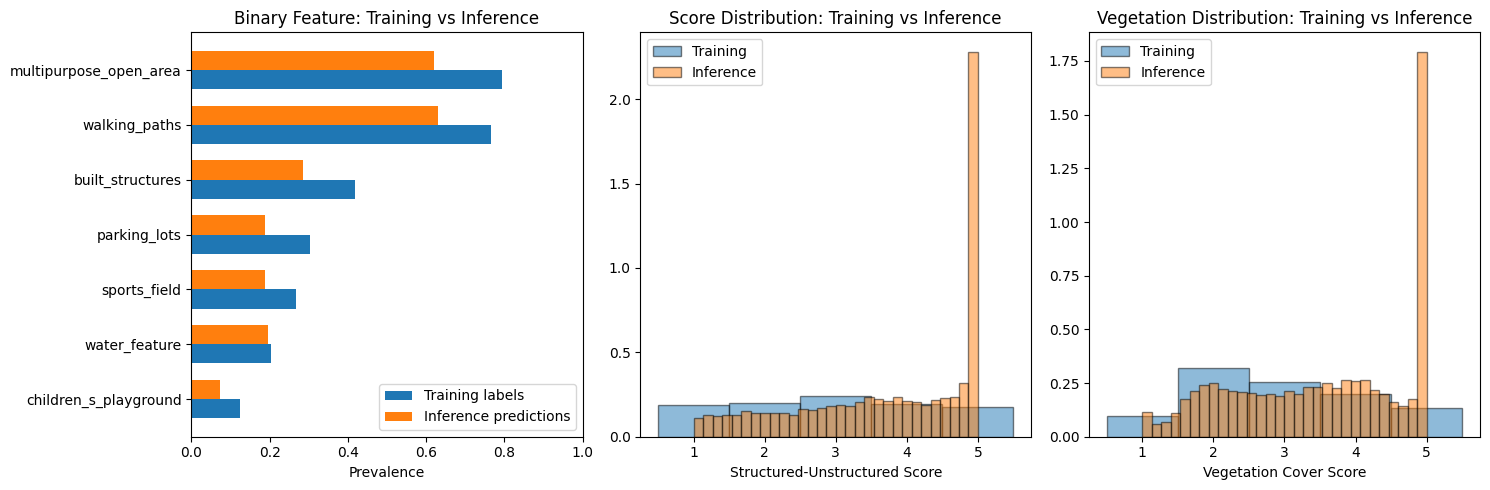

Binary prevalence shift (inference - training):
  multipurpose_open_area         -17.5%
  walking_paths                  -13.6%
  built_structures               -13.4%
  parking_lots                   -11.5%
  sports_field                   -7.8%
  children_s_playground          -5.2%
  water_feature                  -0.7%
Saved: /Users/starsrain/2025_codeProject/GreenSpace_CNN/predictions/train_vs_inference_PyTorch_20260614_220926.png


In [7]:
# Diagnostic only: compare the selected inference population with current training labels.
hard_bin_cols = [name for name in bin_names if name in train_df.columns]
train_prev = train_df[hard_bin_cols].mean().sort_values()
infer_prev = pred_df[[f'{name}_pred' for name in hard_bin_cols]].mean()
infer_prev.index = [column.replace('_pred', '') for column in infer_prev.index]
infer_prev = infer_prev.reindex(train_prev.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(train_prev))
width = 0.35
axes[0].barh(x - width / 2, train_prev.values, height=width, label='Training labels')
axes[0].barh(x + width / 2, infer_prev.values, height=width, label='Inference predictions')
axes[0].set(yticks=x, yticklabels=train_prev.index, xlabel='Prevalence', title='Binary Feature: Training vs Inference', xlim=(0, 1))
axes[0].legend()
axes[1].hist(train_df['score_class'].dropna(), bins=np.arange(0.5, 6.5, 1), alpha=0.5, label='Training', density=True, edgecolor='black')
axes[1].hist(pred_df['score_ev'], bins=30, alpha=0.5, label='Inference', density=True, edgecolor='black')
axes[1].set(xlabel='Structured-Unstructured Score', title='Score Distribution: Training vs Inference')
axes[1].legend()
axes[2].hist(train_df['veg_class'].dropna(), bins=np.arange(0.5, 6.5, 1), alpha=0.5, label='Training', density=True, edgecolor='black')
axes[2].hist(pred_df['veg_ev'], bins=30, alpha=0.5, label='Inference', density=True, edgecolor='black')
axes[2].set(xlabel='Vegetation Cover Score', title='Vegetation Distribution: Training vs Inference')
axes[2].legend()
plt.tight_layout()
comparison_path = out_dir / f'train_vs_inference_{output_tag}.png'
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()

print('Binary prevalence shift (inference - training):')
for name, value in (infer_prev - train_prev).sort_values().items():
    print(f'  {name:<30} {value:+.1%}')
print('Saved:', comparison_path)
